# Lista 1 - Experimentos

**1. (Exercício 2.1-3 do livro do Cormen) Escreva um pseudocódigo para a busca linear e mostre, usando invariância de laço, que o seu algoritmo está correto.**

In [3]:
# Respondido no Mathcha

**2. Implemente o algoritmo de ordenação por inserção e crie uma cópia anotada dele que mede o número de operações no modelo da Random Access Machine (RAM, seção 2.2 livro do Cormen). Usando entradas de tamanho crescente, mostre em um gráfico quando o tempo de execução no modelo RAM diverge de medições feitas em uma máquina real.**

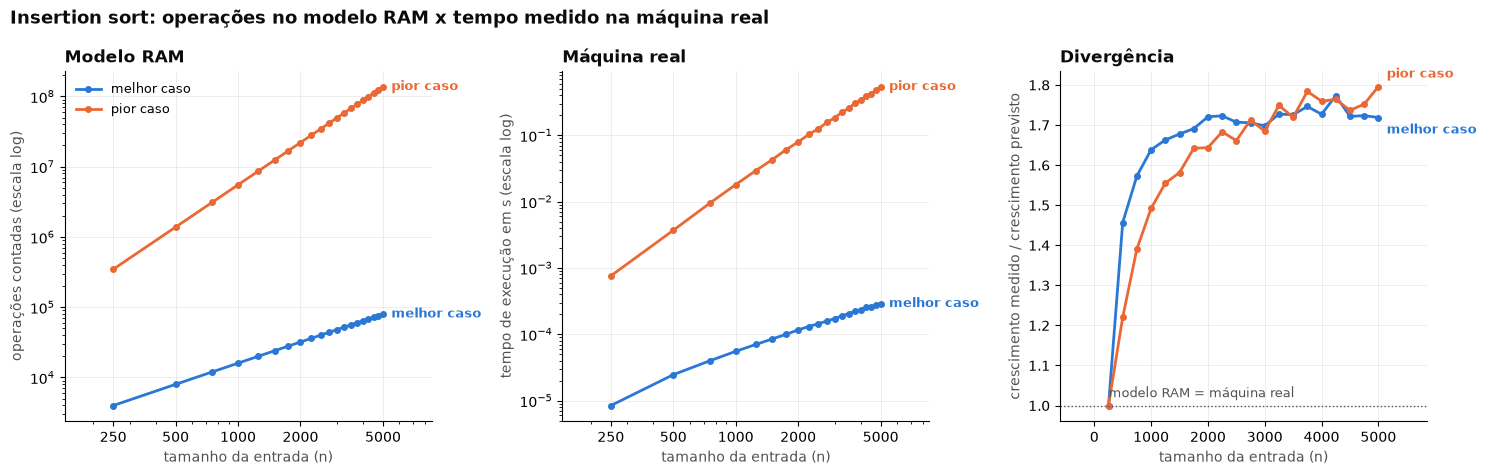

     n |   ops melhor   tempo (s) |     ops pior   tempo (s)
   250 |        3,987    0.000008 |      346,362    0.000760
   500 |        7,987    0.000025 |    1,380,237    0.003698
   750 |       11,987    0.000040 |    3,101,612    0.009472
  1000 |       15,987    0.000055 |    5,510,487    0.018050
  1250 |       19,987    0.000070 |    8,606,862    0.029380
  1500 |       23,987    0.000085 |   12,390,737    0.043020
  1750 |       27,987    0.000100 |   16,862,112    0.060774
  2000 |       31,987    0.000116 |   22,020,987    0.079462
  2250 |       35,987    0.000131 |   27,867,362    0.102962
  2500 |       39,987    0.000144 |   34,401,237    0.125460
  2750 |       43,987    0.000159 |   41,622,612    0.156485
  3000 |       47,987    0.000172 |   49,531,487    0.183153
  3250 |       51,987    0.000190 |   58,127,862    0.223210
  3500 |       55,987    0.000204 |   67,411,737    0.254405
  3750 |       59,987    0.000221 |   77,383,112    0.303058
  4000 |       63,987   

In [4]:
import time

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullFormatter, ScalarFormatter

from ram import insertion_sort_ram
from sorting import insertion_sort

TAMANHOS = list(range(250, 5001, 250))

# melhor caso: lista ja ordenada / pior caso: lista em ordem inversa
# o melhor caso e linear e roda rapido demais, entao repetimos mais vezes
CENARIOS = {
    "melhor caso": {"gera": lambda n: list(range(n)), "repeticoes": 15, "cor": "#2a78d6"},
    "pior caso": {"gera": lambda n: list(range(n, 0, -1)), "repeticoes": 3, "cor": "#eb6834"},
}

TINTA, TINTA_FRACA = "#0b0b0b", "#52514e"


def mede_tempo(lista, repeticoes):
    # menor de N execucoes: reduz o ruido do escalonador do sistema operacional
    melhor = float("inf")
    for _ in range(repeticoes):
        copia = list(lista)
        inicio = time.perf_counter()
        insertion_sort(copia)
        melhor = min(melhor, time.perf_counter() - inicio)
    return melhor


for cenario in CENARIOS.values():
    cenario["operacoes"] = []
    cenario["tempos"] = []
    for n in TAMANHOS:
        lista = cenario["gera"](n)
        # as duas funcoes recebem copias: ambas ordenam a lista no lugar
        cenario["operacoes"].append(insertion_sort_ram(list(lista))[1])
        cenario["tempos"].append(mede_tempo(lista, cenario["repeticoes"]))

    # quanto cada medida cresceu em relacao ao menor n; se o modelo RAM previsse
    # a maquina real, a razao entre os dois crescimentos ficaria colada em 1
    cresc_ops = [o / cenario["operacoes"][0] for o in cenario["operacoes"]]
    cresc_tempo = [t / cenario["tempos"][0] for t in cenario["tempos"]]
    cenario["divergencia"] = [t / o for t, o in zip(cresc_tempo, cresc_ops)]


def rotula(ax, x, y, texto, cor, deslocamento=0):
    ax.annotate(texto, (x, y), xytext=(6, deslocamento), textcoords="offset points",
                color=cor, fontsize=9, va="center", fontweight="bold")


fig, (ax_ram, ax_real, ax_div) = plt.subplots(1, 3, figsize=(15, 4.8))

for nome, cenario in CENARIOS.items():
    cor = cenario["cor"]
    for ax, serie in ((ax_ram, "operacoes"), (ax_real, "tempos"), (ax_div, "divergencia")):
        ax.plot(TAMANHOS, cenario[serie], color=cor, linewidth=2, marker="o", markersize=4, label=nome)
        if ax is not ax_div:
            rotula(ax, TAMANHOS[-1], cenario[serie][-1], nome, cor)

# no painel da divergencia as duas curvas terminam quase no mesmo ponto:
# afasta os rotulos na vertical para que nao fiquem um em cima do outro
ordenados = sorted(CENARIOS.items(), key=lambda par: par[1]["divergencia"][-1])
for deslocamento, (nome, cenario) in zip((-9, 9), ordenados):
    rotula(ax_div, TAMANHOS[-1], cenario["divergencia"][-1], nome, cenario["cor"], deslocamento)

ax_div.axhline(1, color=TINTA_FRACA, linewidth=1, linestyle=":")
ax_div.annotate("modelo RAM = máquina real", (TAMANHOS[0], 1), xytext=(0, 6),
                textcoords="offset points", color=TINTA_FRACA, fontsize=9)

for ax in (ax_ram, ax_real, ax_div):
    ax.set_xlabel("tamanho da entrada (n)", color=TINTA_FRACA)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.margins(x=0.18)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)

# escala log nos dois eixos: separa as curvas e deixa visivel a inclinacao
# de cada uma (1 para o melhor caso linear, 2 para o pior caso quadratico)
for ax in (ax_ram, ax_real):
    ax.set_xscale("log")
    ax.set_yscale("log")
    # a faixa de n nao chega a duas decadas, entao o matplotlib rotularia as
    # marcas menores em notacao cientifica e os numeros ficariam sobrepostos
    ax.xaxis.set_major_locator(FixedLocator([250, 500, 1000, 2000, 5000]))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(NullFormatter())

ax_ram.set_title("Modelo RAM", color=TINTA, loc="left", fontweight="bold")
ax_ram.set_ylabel("operações contadas (escala log)", color=TINTA_FRACA)
ax_real.set_title("Máquina real", color=TINTA, loc="left", fontweight="bold")
ax_real.set_ylabel("tempo de execução em s (escala log)", color=TINTA_FRACA)
ax_div.set_title("Divergência", color=TINTA, loc="left", fontweight="bold")
ax_div.set_ylabel("crescimento medido / crescimento previsto", color=TINTA_FRACA)
ax_ram.legend(frameon=False, fontsize=9, loc="upper left")

fig.suptitle("Insertion sort: operações no modelo RAM x tempo medido na máquina real",
             color=TINTA, fontsize=13, fontweight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

melhor, pior = CENARIOS["melhor caso"], CENARIOS["pior caso"]
print(f"{'n':>6} | {'ops melhor':>12} {'tempo (s)':>11} | {'ops pior':>12} {'tempo (s)':>11}")
for k, n in enumerate(TAMANHOS):
    print(f"{n:>6} | {melhor['operacoes'][k]:>12,} {melhor['tempos'][k]:>11.6f} |"
          f" {pior['operacoes'][k]:>12,} {pior['tempos'][k]:>11.6f}")

Os dois primeiros gráficos mostram a mesma coisa em unidades diferentes: em escala log-log o melhor caso tem inclinação 1 (Θ(n), lista já ordenada, o laço interno nunca executa) e o pior caso tem inclinação 2 (Θ(n²), lista em ordem inversa, o laço interno varre todos os elementos anteriores). Nesse aspecto o modelo RAM acerta — a **forma** da curva medida na máquina real é a mesma que a contagem de operações prevê, nos dois cenários.

A divergência aparece no terceiro gráfico, que divide o crescimento medido pelo crescimento previsto (ambos normalizados pelo menor n). Se o modelo RAM descrevesse a máquina real, essa razão seria constante em 1 — cada operação custaria sempre o mesmo tempo. O que se observa é a razão subindo rápido até cerca de **n ≈ 2000** e estabilizando perto de **1,7**: o tempo real cresce ~70% mais do que o número de operações. O modelo RAM assume custo unitário e uniforme para toda operação, mas na máquina real o custo por operação aumenta com o tamanho da entrada — hierarquia de memória (a lista deixa de caber na cache), overhead do interpretador e alocação dinâmica. Para entradas pequenas o efeito é oposto: o custo fixo de chamada dilui as diferenças e a medição fica dominada por ruído.


**3. Mostre numericamente com suas implementações dos algoritmos de insertion-sort e merge sort como se comporta o desempenho de cada algoritmo utilizando entradas de tamanho crescente, considerando entradas de pior caso, melhor caso e caso médio. Analise, para cada tipo de entrada, se existe algum ponto a partir do qual um algoritmo passa a ser mais rápido que o outro.**

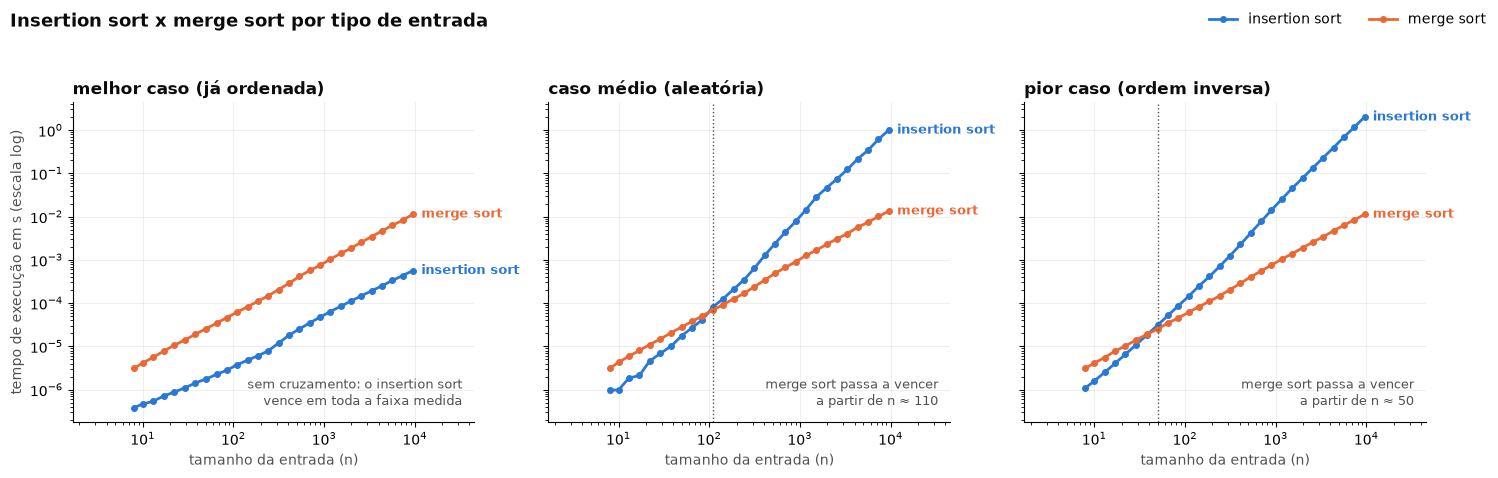


melhor caso (já ordenada)
     n   insertion (s)     merge (s)   insertion/merge
     8       0.0000004     0.0000031              0.12
    10       0.0000005     0.0000041              0.11
    13       0.0000005     0.0000056              0.10
    17       0.0000007     0.0000077              0.09
    22       0.0000009     0.0000105              0.08
    29       0.0000011     0.0000140              0.08
    38       0.0000014     0.0000190              0.07
    50       0.0000018     0.0000258              0.07
    65       0.0000022     0.0000340              0.07
    84       0.0000028     0.0000462              0.06
   110       0.0000038     0.0000616              0.06
   143       0.0000048     0.0000823              0.06
   186       0.0000060     0.0001101              0.05
   242       0.0000079     0.0001479              0.05
   314       0.0000119     0.0002050              0.06
   409       0.0000181     0.0002863              0.06
   532       0.0000253     0.0004136  

In [5]:
import random
from time import perf_counter

import matplotlib.pyplot as plt

from sorting import insertion_sort, merge_sort

# grade geometrica: mais pontos nos tamanhos pequenos, onde fica o cruzamento
TAMANHOS = sorted({int(8 * 1.3 ** k) for k in range(28)})

ALGORITMOS = {
    "insertion sort": {"func": insertion_sort, "cor": "#2a78d6"},
    "merge sort": {"func": merge_sort, "cor": "#eb6834"},
}

# o tipo de entrada e o que define melhor/pior caso do insertion sort;
# o merge sort divide a lista sempre do mesmo jeito e nao se importa com a ordem
CENARIOS = {
    "melhor caso (já ordenada)": lambda n: list(range(n)),
    "caso médio (aleatória)": lambda n: random.sample(range(n), n),
    "pior caso (ordem inversa)": lambda n: list(range(n, 0, -1)),
}

TINTA, TINTA_FRACA = "#0b0b0b", "#52514e"


def mede_tempo(func, lista, orcamento=0.02, max_rep=300):
    # repete ate gastar o orcamento de tempo: entradas pequenas sao medidas
    # muitas vezes, entradas grandes poucas; fica com a menor execucao
    melhor, gasto, repeticoes = float("inf"), 0.0, 0
    while repeticoes < max_rep and gasto < orcamento:
        copia = list(lista)
        inicio = perf_counter()
        func(copia)
        decorrido = perf_counter() - inicio
        melhor = min(melhor, decorrido)
        gasto += decorrido
        repeticoes += 1
    return melhor


random.seed(2316)
medidas = {(cenario, nome): [] for cenario in CENARIOS for nome in ALGORITMOS}
for cenario, gera in CENARIOS.items():
    for n in TAMANHOS:
        lista = gera(n)
        for nome, algoritmo in ALGORITMOS.items():
            medidas[(cenario, nome)].append(mede_tempo(algoritmo["func"], lista))


def cruzamento(cenario):
    # primeiro tamanho a partir do qual o merge sort vence e nao perde mais
    ins, mrg = medidas[(cenario, "insertion sort")], medidas[(cenario, "merge sort")]
    for k in range(len(TAMANHOS)):
        if all(mrg[j] < ins[j] for j in range(k, len(TAMANHOS))):
            return k
    return None


fig, eixos = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, cenario in zip(eixos, CENARIOS):
    for nome, algoritmo in ALGORITMOS.items():
        serie = medidas[(cenario, nome)]
        ax.plot(TAMANHOS, serie, color=algoritmo["cor"], linewidth=2,
                marker="o", markersize=4, label=nome)
        ax.annotate(nome, (TAMANHOS[-1], serie[-1]), xytext=(6, 0), textcoords="offset points",
                    color=algoritmo["cor"], fontsize=9, va="center", fontweight="bold")

    k = cruzamento(cenario)
    if k is None:
        texto = "sem cruzamento: o insertion sort\nvence em toda a faixa medida"
    else:
        texto = f"merge sort passa a vencer\na partir de n ≈ {TAMANHOS[k]}"
        ax.axvline(TAMANHOS[k], color=TINTA_FRACA, linewidth=1, linestyle=":")
    ax.annotate(texto, (0.97, 0.04), xycoords="axes fraction", ha="right", va="bottom",
                color=TINTA_FRACA, fontsize=9)

    ax.set_title(cenario, color=TINTA, loc="left", fontweight="bold")
    # escala log nos dois eixos: a faixa de n vai de 8 a ~9500 e a de tempo
    # cobre 6 ordens de grandeza, entao em escala linear so o pior caso apareceria
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("tamanho da entrada (n)", color=TINTA_FRACA)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.margins(x=0.22)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)

eixos[0].set_ylabel("tempo de execução em s (escala log)", color=TINTA_FRACA)

fig.suptitle("Insertion sort x merge sort por tipo de entrada",
             color=TINTA, fontsize=13, fontweight="bold", x=0.01, ha="left")
fig.legend(*eixos[0].get_legend_handles_labels(), loc="upper right",
           ncols=2, frameon=False, fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

for cenario in CENARIOS:
    k = cruzamento(cenario)
    print(f"\n{cenario}")
    print(f"{'n':>6} {'insertion (s)':>15} {'merge (s)':>13} {'insertion/merge':>17}")
    for i, n in enumerate(TAMANHOS):
        ins = medidas[(cenario, "insertion sort")][i]
        mrg = medidas[(cenario, "merge sort")][i]
        marca = "  <- a partir daqui o merge sort vence" if k == i else ""
        print(f"{n:>6} {ins:>15.7f} {mrg:>13.7f} {ins / mrg:>17.2f}{marca}")

O tipo de entrada é o que separa melhor, médio e pior caso **do insertion sort** — o merge sort divide a lista pela metade sempre do mesmo jeito, faz Θ(n log n) comparações independentemente da ordem inicial e, de fato, seus tempos são praticamente iguais nos três cenários (em n = 9540: 0,011 s ordenada, 0,013 s aleatória, 0,011 s inversa).

**Melhor caso (lista já ordenada) — não existe cruzamento.** O insertion sort é Θ(n) aqui (o laço interno nunca executa) contra Θ(n log n) do merge sort, então a vantagem *aumenta* com n em vez de desaparecer: em n = 9540 o insertion sort é ~19× mais rápido. Nenhum tamanho na faixa medida inverte isso, e nem deveria — o fator log n só cresce.

**Caso médio (lista aleatória) — cruzamento em n ≈ 110.** Abaixo disso o insertion sort vence (em n = 8 ele é ~3× mais rápido); acima, a diferença cresce sem limite: 2× em n ≈ 240, 11× em n ≈ 1170, 77× em n = 9540.

**Pior caso (ordem inversa) — cruzamento em n ≈ 50.** O mesmo padrão, mas o cruzamento acontece mais cedo porque o insertion sort já está no seu Θ(n²) pleno desde o começo. Em n = 9540 o merge sort é 180× mais rápido.

A leitura geral é que o cruzamento é um efeito de **constantes**, não de ordem de crescimento. O merge sort tem a melhor complexidade assintótica nos dois cenários não-ordenados, mas paga recursão e alocação de listas novas a cada `_merge`; o insertion sort não aloca nada e tem laço apertado. Enquanto n é pequeno, as constantes dominam o log n e o insertion sort ganha. É exatamente por isso que implementações de produção (o Timsort do próprio Python, por exemplo) são híbridas: usam merge sort na estrutura geral e trocam para insertion sort nos blocos abaixo de algumas dezenas de elementos — faixa compatível com os cruzamentos medidos aqui.

Uma ressalva sobre os números: os cruzamentos dependem da máquina e da implementação. A grade de tamanhos é geométrica (razão 1,3), então a localização do cruzamento tem resolução de ±30%; o que é estável entre execuções é a ordem de grandeza (dezenas de elementos), não o valor exato.
